<a href="https://colab.research.google.com/github/Page0526/survival-prediction/blob/main/TCGA_RNA_seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download Data and Install Libs

In [2]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

page0526_tcga_5_subset_path = kagglehub.dataset_download('page0526/tcga-5-subset')

print('Data source import complete.')


Data source import complete.


In [3]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 13.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=65109c8fce3b288077dbff645eb49c9faa392bba6c29964e7ff4fdc61b180881
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [4]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Optional

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from lifelines.utils import concordance_index
from sklearn.preprocessing import StandardScaler

# Exploratory Data Analysis

In [6]:
blca_df = pd.read_csv(f"{page0526_tcga_5_subset_path}/tcga_blca_all_clean.csv")

In [7]:
blca_df.head()

,case_id,slide_id,site,is_female,oncotree_code,age,survival_months,censorship,train,NDUFS5_cnv,...,ZWINT_rnaseq,ZXDA_rnaseq,ZXDB_rnaseq,ZXDC_rnaseq,ZYG11A_rnaseq,ZYG11B_rnaseq,ZYX_rnaseq,ZZEF1_rnaseq,ZZZ3_rnaseq,TPTEP1_rnaseq
0,TCGA-2F-A9KO,TCGA-2F-A9KO-01Z-00-DX1.195576CF-B739-4BD9-B15...,2F,0,BLCA,63,24.11,0,1.0,-1,...,-0.8388,4.1375,3.9664,1.8437,-0.3959,-0.2561,-0.2866,1.8770,-0.3179,-0.3633
1,TCGA-2F-A9KP,TCGA-2F-A9KP-01Z-00-DX1.3CDF534E-958F-4467-AA7...,2F,0,BLCA,66,11.96,0,1.0,2,...,-0.1083,0.3393,0.2769,1.7320,-0.0975,2.6955,-0.6741,1.0323,1.2766,-0.3982
2,TCGA-2F-A9KP,TCGA-2F-A9KP-01Z-00-DX2.718C82A3-252B-498E-BFB...,2F,0,BLCA,66,11.96,0,1.0,2,...,-0.1083,0.3393,0.2769,1.7320,-0.0975,2.6955,-0.6741,1.0323,1.2766,-0.3982
3,TCGA-2F-A9KQ,TCGA-2F-A9KQ-01Z-00-DX1.1C8CB2DD-5CC6-4E99-A0F...,2F,0,BLCA,69,94.81,1,1.0,0,...,-0.4155,1.6846,0.7711,-0.3061,-0.5016,2.8548,-0.6171,-0.8608,-0.0486,-0.3962
4,TCGA-2F-A9KR,TCGA-2F-A9KR-01Z-00-DX1.D6A4BD2D-18F3-4FA6-827...,2F,1,BLCA,59,104.57,0,1.0,0,...,-0.8143,0.8344,1.5075,3.6068,-0.5004,-0.0747,-0.2185,-0.4379,1.6913,1.7748


In [8]:
blca_df.describe()

,is_female,age,survival_months,censorship,train,NDUFS5_cnv,MACF1_cnv,RNA5SP44_cnv,KIAA0754_cnv,BMP8A_cnv,...,ZWINT_rnaseq,ZXDA_rnaseq,ZXDB_rnaseq,ZXDC_rnaseq,ZYG11A_rnaseq,ZYG11B_rnaseq,ZYX_rnaseq,ZZEF1_rnaseq,ZZZ3_rnaseq,TPTEP1_rnaseq
count,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,...,437.000000,437.000000,437.000000,437.00000,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000
mean,0.251716,67.997712,27.415057,0.540046,0.887872,0.144165,0.167048,0.160183,0.162471,0.167048,...,0.071681,0.065703,0.119302,0.32713,0.184549,0.169060,-0.021081,-0.274432,0.259078,-0.081070
std,0.434496,10.644700,25.702726,0.498965,0.315886,0.723012,0.733856,0.727550,0.731758,0.733856,...,1.068212,0.999137,1.152723,1.26924,1.677983,1.115441,0.980554,1.126970,1.815057,0.860026
min,0.000000,34.000000,0.490000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.782200,-1.770100,-1.813000,-2.54570,-0.550900,-2.035600,-1.646200,-2.198300,-2.392500,-0.415700
25%,0.000000,60.000000,11.070000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.759300,-0.611600,-0.616600,-0.49620,-0.496200,-0.649100,-0.685500,-1.015700,-0.643600,-0.395400
50%,0.000000,69.000000,18.560000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.020800,-0.124100,-0.163300,0.20220,-0.370900,-0.003700,-0.286600,-0.392100,0.074800,-0.359000
75%,1.000000,76.000000,32.980000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.660100,0.667900,0.565700,0.99830,0.186600,0.784400,0.381000,0.192200,0.875500,-0.230500
max,1.000000,90.000000,163.170000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,4.953500,7.411700,7.936400,7.56020,20.004000,4.634000,4.367100,6.027000,22.265100,8.025000


# Self-normalizing Network for Survival Prediction Using Genomica Data Only

Loading data for 5-fold cross-validation …
Total samples : 437  |  CNV=1656, RNA-seq=18369

──────────────────────────────────────────────────────────────
Fold 1/5  (train=349, val=88)
──────────────────────────────────────────────────────────────
Feature selection …
  Variance filter : CNV 1656→1656, RNA-seq 18369→18351
    Log-rank: 1656 → top 30 … done  (best p = 1.11e-03)
    Log-rank: 18351 → top 100 … done  (best p = 1.17e-09)
SNN  size=tiny  input=132  bins=4  params=12,932
  Epoch 001/200  loss=2.0055  train_ci=0.5236  val_ci=0.5447  val_acc=0.250  lr=2.00e-04
  Epoch 020/200  loss=1.9132  train_ci=0.5953  val_ci=0.5466  val_acc=0.261  lr=1.00e-04
  Early stopping at epoch 38
Fold 1 best C-index : 0.5543

──────────────────────────────────────────────────────────────
Fold 2/5  (train=349, val=88)
──────────────────────────────────────────────────────────────
Feature selection …
  Variance filter : CNV 1656→1656, RNA-seq 18369→18357
    Log-rank: 1656 → top 30 … done  (best p = 

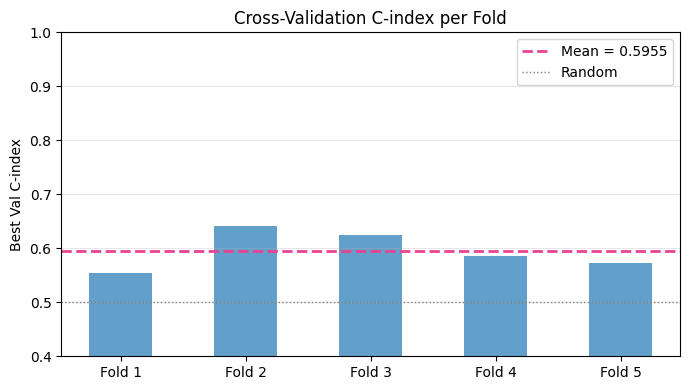

In [10]:
"""
Survival Neural Network (SNN) for TCGA RNA-seq Multi-Cancer Datasets
Supports: BLCA, BRCA, GBMLGG, LUAD, UCEC

Architecture : SNN (SELU + AlphaDropout blocks) from PORPOISE/MCAT
Survival     : Discrete-time NLL loss (hazard per time bin)
Features     : Variance filter → log-rank top-K → StandardScaler
Training     : Full-batch + k-fold cross-validation
"""

import os
import copy
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Optional

import torch
import torch.nn as nn
import torch.optim as optim

from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)


# ─────────────────────────────────────────────────────────────
# 1. CONFIG
# ─────────────────────────────────────────────────────────────

class Config:
    # ── Data ─────────────────────────────────────────────────
    DATA_DIR        = f"{page0526_tcga_5_subset_path}"
    # CANCER_TYPES    = ["BLCA", "BRCA", "GBMLGG", "LUAD", "UCEC"]
    CANCER_TYPE = 'blca'
    CLINICAL_COLS   = ["is_female", "age"]
    SURVIVAL_COL    = "survival_months"
    EVENT_COL       = "censorship"      # 1 = event observed, 0 = censored
    TRAIN_COL       = "train"
    CNV_SUFFIX      = "_cnv"
    RNASEQ_SUFFIX   = "_rnaseq"

    # ── Feature selection ────────────────────────────────────
    VARIANCE_THRESHOLD  = 0.01
    TOP_K_CNV           = 30        # reduced: was 100
    TOP_K_RNASEQ        = 100       # reduced: was 400
    USE_PCA             = False
    PCA_COMPONENTS      = 64

    # ── SNN architecture ─────────────────────────────────────
    # "tiny"  → [64, 64]             (~17k params for input=132)
    # "small" → [256, 256, 256, 256] (too large for n=388)
    # "big"   → [1024,1024,1024,256]
    MODEL_SIZE      = "tiny"
    N_CLASSES       = 4             # discrete survival time bins
    DROPOUT_FIRST   = 0.3           # was 0.0 — input layer needs regularisation
    DROPOUT         = 0.6           # was 0.25 — heavier dropout to fight overfitting

    # ── Training ─────────────────────────────────────────────
    EPOCHS          = 200
    LR              = 2e-4
    WEIGHT_DECAY    = 1e-3          # was 1e-5 — stronger L2
    PATIENCE        = 30
    LR_PATIENCE     = 10
    LR_FACTOR       = 0.5
    LR_MIN          = 1e-6
    DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"

    # ── Cross-validation ─────────────────────────────────────
    N_FOLDS         = 5

    # ── Misc ─────────────────────────────────────────────────
    SEED            = 42
    SAVE_DIR        = "./checkpoints"
    LOG_EVERY       = 20


# ─────────────────────────────────────────────────────────────
# 2. SNN BUILDING BLOCKS
# ─────────────────────────────────────────────────────────────

class SNN_Block(nn.Module):
    """Linear → SELU → AlphaDropout. AlphaDropout preserves self-normalizing."""
    def __init__(self, dim1: int, dim2: int, dropout: float = 0.25):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim1, dim2),
            nn.SELU(),
            nn.AlphaDropout(p=dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


def init_max_weights(module: nn.Module):
    """Truncated-normal init scaled by fan-in — works well with SELU."""
    for m in module.modules():
        if isinstance(m, nn.Linear):
            stdv = 1. / np.sqrt(m.weight.size(1))
            nn.init.trunc_normal_(m.weight, std=stdv)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.)


# ─────────────────────────────────────────────────────────────
# 3. SNN MODEL
# ─────────────────────────────────────────────────────────────

class SNN(nn.Module):
    """
    Genomic SNN for discrete-time survival prediction.

    Input  : concatenated feature vector (clinical + CNV + RNA-seq)
    Output : (hazards, S, Y_hat)
               hazards : (B, n_classes)  sigmoid hazard per time bin
               S       : (B, n_classes)  cumulative survival S(t)
               Y_hat   : (B, 1)          predicted time bin
    """
    SIZE_DICT = {
        "tiny":  [64, 64],
        "small": [256, 256, 256, 256],
        "big":   [1024, 1024, 1024, 256],
    }

    def __init__(self, input_dim: int,
                 model_size: str = "tiny",
                 n_classes: int = 4,
                 dropout_first: float = 0.3,
                 dropout: float = 0.6):
        super(SNN, self).__init__()
        self.n_classes = n_classes
        hidden = self.SIZE_DICT[model_size]

        fc_omic = [SNN_Block(dim1=input_dim, dim2=hidden[0], dropout=dropout_first)]
        for i in range(len(hidden) - 1):
            fc_omic.append(SNN_Block(dim1=hidden[i], dim2=hidden[i + 1],
                                     dropout=dropout))
        self.fc_omic    = nn.Sequential(*fc_omic)
        self.classifier = nn.Linear(hidden[-1], n_classes)
        init_max_weights(self)

    def forward(self, x: torch.Tensor):
        features = self.fc_omic(x)
        logits   = self.classifier(features)           # (B, n_classes)
        Y_hat    = torch.topk(logits, 1, dim=1)[1]    # (B, 1)
        hazards  = torch.sigmoid(logits)               # (B, n_classes)
        S        = torch.cumprod(1 - hazards, dim=1)  # (B, n_classes)
        return hazards, S, Y_hat

    def relocate(self):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if torch.cuda.device_count() > 1:
            device_ids = list(range(torch.cuda.device_count()))
            self.fc_omic = nn.DataParallel(
                self.fc_omic, device_ids=device_ids).to("cuda:0")
        else:
            self.fc_omic = self.fc_omic.to(device)
        self.classifier = self.classifier.to(device)


# ─────────────────────────────────────────────────────────────
# 4. LOSS
# ─────────────────────────────────────────────────────────────

def nll_survival_loss(hazards: torch.Tensor,
                      S: torch.Tensor,
                      Y: torch.Tensor,
                      c: torch.Tensor) -> torch.Tensor:
    """
    Discrete-time NLL survival loss.
      hazards : (B, n_classes)
      S       : (B, n_classes)  cumulative survival
      Y       : (B,) long       ground-truth time bin
      c       : (B,) float      1=censored, 0=event  (flipped from EVENT_COL)
    """
    S_pad    = torch.cat([torch.ones_like(S[:, :1]), S], dim=1)  # prepend S(0)=1
    Y_idx    = Y.view(-1, 1)
    s_prev   = torch.gather(S_pad, 1, Y_idx).squeeze(1)
    h_t      = torch.gather(hazards, 1, Y_idx).squeeze(1)
    s_t      = torch.gather(S, 1, Y_idx).squeeze(1)

    l_uncens = -torch.log(h_t + 1e-7) - torch.log(s_prev + 1e-7)
    l_cens   = -torch.log(s_t + 1e-7)
    return ((1.0 - c) * l_uncens + c * l_cens).mean()


def bin_survival_times(survival_times: np.ndarray,
                       n_bins: int,
                       eps: float = 1e-6,
                       cuts: Optional[np.ndarray] = None):
    """Quantile-bin survival times. Fit cuts on train, reuse for val/test."""
    if cuts is None:
        cuts      = np.quantile(survival_times, np.linspace(0, 1, n_bins + 1))
        cuts[0]  -= eps
        cuts[-1] += eps
    indices = np.clip(np.digitize(survival_times, bins=cuts[1:-1]), 0, n_bins - 1)
    return indices.astype(int), cuts


# ─────────────────────────────────────────────────────────────
# 5. FEATURE SELECTION
# ─────────────────────────────────────────────────────────────

def logrank_selection(X_train: pd.DataFrame,
                      y_train: pd.DataFrame,
                      top_k: int,
                      survival_col: str,
                      event_col: str) -> list:
    print(f"    Log-rank: {X_train.shape[1]} → top {top_k}",
          end=" … ", flush=True)
    T, E = y_train[survival_col].values, y_train[event_col].values
    p_vals = {}
    for col in X_train.columns:
        vals = X_train[col].values
        med  = np.median(vals)
        lo, hi = vals <= med, vals > med
        if lo.sum() < 2 or hi.sum() < 2:
            p_vals[col] = 1.0; continue
        try:
            p_vals[col] = logrank_test(T[lo], T[hi], E[lo], E[hi]).p_value
        except Exception:
            p_vals[col] = 1.0
    selected = sorted(p_vals, key=p_vals.get)[:top_k]
    print(f"done  (best p = {p_vals[selected[0]]:.2e})")
    return selected


def select_features(train_df: pd.DataFrame,
                    cnv_cols: list,
                    rnaseq_cols: list,
                    cfg: Config):
    y = train_df[[cfg.SURVIVAL_COL, cfg.EVENT_COL]]

    def var_filter(cols):
        vt = VarianceThreshold(threshold=cfg.VARIANCE_THRESHOLD)
        vt.fit(train_df[cols])
        return [c for c, ok in zip(cols, vt.get_support()) if ok]

    cnv_v = var_filter(cnv_cols)    if cnv_cols    else []
    rna_v = var_filter(rnaseq_cols) if rnaseq_cols else []
    print(f"  Variance filter : CNV {len(cnv_cols)}→{len(cnv_v)}, "
          f"RNA-seq {len(rnaseq_cols)}→{len(rna_v)}")

    if cfg.USE_PCA:
        all_g = cnv_v + rna_v
        pca   = PCA(n_components=min(cfg.PCA_COMPONENTS, len(all_g)),
                    random_state=cfg.SEED)
        pca.fit(train_df[all_g])
        ev = pca.explained_variance_ratio_.cumsum()[-1]
        print(f"  PCA : {len(all_g)} → {pca.n_components_} comps ({ev*100:.1f}% var)")
        return [], [], pca, all_g

    sel_cnv = logrank_selection(
        train_df[cnv_v], y, min(cfg.TOP_K_CNV, len(cnv_v)),
        cfg.SURVIVAL_COL, cfg.EVENT_COL) if cnv_v else []
    sel_rna = logrank_selection(
        train_df[rna_v], y, min(cfg.TOP_K_RNASEQ, len(rna_v)),
        cfg.SURVIVAL_COL, cfg.EVENT_COL)
    return sel_cnv, sel_rna, None, None


# ─────────────────────────────────────────────────────────────
# 6. DATASET
# ─────────────────────────────────────────────────────────────

class SurvivalTensors:
    def __init__(self, df, feature_cols, bin_indices, cfg):
        dev = cfg.DEVICE
        self.X = torch.tensor(
            df[feature_cols].values, dtype=torch.float32).to(dev)
        self.Y = torch.tensor(bin_indices, dtype=torch.long).to(dev)
        self.c = torch.tensor(
            1.0 - df[cfg.EVENT_COL].values, dtype=torch.float32).to(dev)
        self.T_raw = df[cfg.SURVIVAL_COL].values
        self.E_raw = df[cfg.EVENT_COL].values.astype(bool)


# ─────────────────────────────────────────────────────────────
# 7. DATA LOADING  — split into two helpers for CV reuse
# ─────────────────────────────────────────────────────────────

def load_raw_data(cfg: Config) -> tuple[pd.DataFrame, list, list]:
    """
    Step 1 — load CSVs, cast types, drop bad rows.
    Returns (clean_df, cnv_cols, rnaseq_cols).
    Called once; result is shared across all CV folds.
    """
    frames = []
    # for ct in cfg.CANCER_TYPES:
    #     p = Path(cfg.DATA_DIR) / f"{ct}.csv"
    #     if p.exists():
    #         df = pd.read_csv(p); df["cancer_type"] = ct
    #         frames.append(df)
    #         print(f"  Loaded {ct}: {len(df):,} samples")
    # if not frames:
    #     mp = Path(cfg.DATA_DIR) / "merged.csv"
    #     if not mp.exists():
    #         raise FileNotFoundError(
    #             f"No data in '{cfg.DATA_DIR}'. Add per-cancer CSVs or merged.csv.")
    #     frames.append(pd.read_csv(mp))
    #     print(f"  Loaded merged.csv: {len(frames[0]):,} samples")

    # df_all = pd.concat(frames, ignore_index=True)
    ct = cfg.CANCER_TYPE
    p = Path(cfg.DATA_DIR) / f"tcga_{ct}_all_clean.csv"
    df = pd.read_csv(p)
    df_all = df
    df_all = df_all[pd.to_numeric(
        df_all[cfg.SURVIVAL_COL], errors="coerce").notna()].reset_index(drop=True)

    cnv_cols    = [c for c in df_all.columns if c.endswith(cfg.CNV_SUFFIX)]
    rnaseq_cols = [c for c in df_all.columns if c.endswith(cfg.RNASEQ_SUFFIX)]
    all_feat    = cfg.CLINICAL_COLS + cnv_cols + rnaseq_cols

    for col in all_feat + [cfg.SURVIVAL_COL, cfg.EVENT_COL]:
        df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

    df_all = df_all.dropna(
        subset=all_feat + [cfg.SURVIVAL_COL, cfg.EVENT_COL])
    df_all = df_all[df_all[cfg.SURVIVAL_COL] > 0].reset_index(drop=True)

    print(f"Total samples : {len(df_all):,}  |  "
          f"CNV={len(cnv_cols)}, RNA-seq={len(rnaseq_cols)}")
    return df_all, cnv_cols, rnaseq_cols


def prepare_fold(train_df: pd.DataFrame,
                 val_df: pd.DataFrame,
                 cnv_cols: list,
                 rnaseq_cols: list,
                 cfg: Config) -> tuple:
    """
    Step 2 — feature selection, scaling, binning for one train/val split.
    Everything is fitted on train_df only to prevent leakage.
    Returns (train_data, val_data, meta).
    """
    # Feature selection (train only)
    sel_cnv, sel_rna, pca_obj, pca_src = select_features(
        train_df, cnv_cols, rnaseq_cols, cfg)

    feature_cols = cfg.CLINICAL_COLS + sel_cnv + sel_rna
    scale_cols   = pca_src if pca_obj else feature_cols

    # Scale (fit on train)
    scaler = StandardScaler()
    train_df = train_df.copy(); val_df = val_df.copy()
    train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
    val_df[scale_cols]   = scaler.transform(val_df[scale_cols])

    # Apply PCA if requested
    if pca_obj:
        pca_cols = [f"pc_{i}" for i in range(pca_obj.n_components_)]
        for df in (train_df, val_df):
            comps = pca_obj.transform(df[pca_src])
            for j, pc in enumerate(pca_cols):
                df[pc] = comps[:, j]
        feature_cols = cfg.CLINICAL_COLS + pca_cols

    # Bin survival times (cuts fitted on train)
    tr_bins, cuts = bin_survival_times(
        train_df[cfg.SURVIVAL_COL].values, cfg.N_CLASSES)
    va_bins, _    = bin_survival_times(
        val_df[cfg.SURVIVAL_COL].values, cfg.N_CLASSES, cuts=cuts)

    train_data = SurvivalTensors(train_df, feature_cols, tr_bins, cfg)
    val_data   = SurvivalTensors(val_df,   feature_cols, va_bins, cfg)
    meta       = dict(feature_cols=feature_cols, scaler=scaler,
                      pca_obj=pca_obj, pca_src=pca_src,
                      sel_cnv=sel_cnv, sel_rna=sel_rna, cuts=cuts)
    return train_data, val_data, meta


def load_and_preprocess(cfg: Config):
    """
    Single train/val split using the pre-assigned 'train' column.
    Calls load_raw_data + prepare_fold internally.
    Used by train(); cross_validate() calls these helpers directly.
    """
    df_all, cnv_cols, rnaseq_cols = load_raw_data(cfg)
    tc   = pd.to_numeric(df_all[cfg.TRAIN_COL], errors="coerce")
    mask = tc.fillna(0).astype(int) == 1 if not tc.isna().all() else \
           df_all[cfg.TRAIN_COL].astype(str).str.strip().str.lower() \
               .isin(["1","true","yes"])

    train_df = df_all[mask].copy()
    val_df   = df_all[~mask].copy()
    print(f"Train / Val : {len(train_df):,} / {len(val_df):,}")

    if len(train_df) == 0:
        raise ValueError(f"Train split empty — check '{cfg.TRAIN_COL}' column.")
    if len(val_df) == 0:
        from sklearn.model_selection import train_test_split
        idx_tr, idx_val = train_test_split(
            df_all.index, test_size=0.2, random_state=cfg.SEED)
        train_df = df_all.loc[idx_tr].copy()
        val_df   = df_all.loc[idx_val].copy()

    return prepare_fold(train_df, val_df, cnv_cols, rnaseq_cols, cfg)


# ─────────────────────────────────────────────────────────────
# 8. EVALUATION
# ─────────────────────────────────────────────────────────────

@torch.no_grad()
def evaluate(model: SNN, data: SurvivalTensors) -> dict:
    model.eval()
    hazards, S, Y_hat = model(data.X)
    risk = hazards.mean(dim=1).cpu().numpy()
    ci   = concordance_index(data.T_raw, -risk, data.E_raw)
    acc  = (Y_hat.squeeze(1).cpu() == data.Y.cpu()).float().mean().item()
    return {"cindex": ci, "bin_acc": acc}


# ─────────────────────────────────────────────────────────────
# 9. TRAINING (single split)
# ─────────────────────────────────────────────────────────────

def _build_and_train(train_data: SurvivalTensors,
                     val_data: SurvivalTensors,
                     meta: dict,
                     cfg: Config,
                     verbose: bool = True) -> tuple:
    """
    Core training loop — used by both train() and cross_validate().
    Returns (model, history).
    """
    input_dim = len(meta["feature_cols"])
    model = SNN(
        input_dim     = input_dim,
        model_size    = cfg.MODEL_SIZE,
        n_classes     = cfg.N_CLASSES,
        dropout_first = cfg.DROPOUT_FIRST,
        dropout       = cfg.DROPOUT,
    )
    model.relocate()

    if verbose:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"SNN  size={cfg.MODEL_SIZE}  input={input_dim}  "
              f"bins={cfg.N_CLASSES}  params={n_p:,}")

    optimizer = optim.Adam(
        model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=cfg.LR_FACTOR,
        patience=cfg.LR_PATIENCE, min_lr=cfg.LR_MIN)

    best_ci, patience_ctr = 0.0, 0
    history = {"train_loss": [], "train_ci": [], "val_ci": [], "val_acc": []}

    for epoch in range(1, cfg.EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        hazards, S, _ = model(train_data.X)
        loss = nll_survival_loss(hazards, S, train_data.Y, train_data.c)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        tr  = evaluate(model, train_data)
        val = evaluate(model, val_data)
        scheduler.step(val["cindex"])
        lr  = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(loss.item())
        history["train_ci"].append(tr["cindex"])
        history["val_ci"].append(val["cindex"])
        history["val_acc"].append(val["bin_acc"])

        if verbose and (epoch % cfg.LOG_EVERY == 0 or epoch == 1):
            print(f"  Epoch {epoch:03d}/{cfg.EPOCHS}  "
                  f"loss={loss.item():.4f}  "
                  f"train_ci={tr['cindex']:.4f}  "
                  f"val_ci={val['cindex']:.4f}  "
                  f"val_acc={val['bin_acc']:.3f}  "
                  f"lr={lr:.2e}")

        if val["cindex"] > best_ci:
            best_ci      = val["cindex"]
            patience_ctr = 0
            best_state   = copy.deepcopy(model.state_dict())
        else:
            patience_ctr += 1
            if patience_ctr >= cfg.PATIENCE:
                if verbose:
                    print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)   # restore best weights
    return model, history, best_ci


def train(cfg: Config):
    """Single train/val run using the pre-assigned 'train' column."""
    cfg.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(cfg.SEED); np.random.seed(cfg.SEED)
    os.makedirs(cfg.SAVE_DIR, exist_ok=True)

    print("=" * 62)
    print("Loading data …")
    train_data, val_data, meta = load_and_preprocess(cfg)

    print("\n" + "=" * 62)
    print("Training …\n")
    model, history, best_ci = _build_and_train(
        train_data, val_data, meta, cfg, verbose=True)

    torch.save({
        "model_state": model.state_dict(),
        "val_cindex":  best_ci,
        "input_dim":   len(meta["feature_cols"]),
        "meta":        meta,
        "config":      cfg.__dict__,
    }, Path(cfg.SAVE_DIR) / "best_snn.pt")

    print(f"\n{'='*62}")
    print(f"Best Val C-index : {best_ci:.4f}")
    print(f"Checkpoint       : {cfg.SAVE_DIR}/best_snn.pt")
    return model, history


# ─────────────────────────────────────────────────────────────
# 10. CROSS-VALIDATION  ← integrated here, after train()
# ─────────────────────────────────────────────────────────────

def cross_validate(cfg: Config, n_folds: int = None) -> list:
    """
    Stratified k-fold cross-validation.

    Stratification is on the event indicator so each fold has a
    balanced censoring ratio — important with only ~400 samples.

    Each fold:
      - fits feature selection and scaler on that fold's training data only
        (no leakage between folds)
      - trains a fresh SNN and records the best val C-index

    Returns list of per-fold best C-index values and prints mean ± std.

    Usage:
        cfg = Config()
        fold_scores = cross_validate(cfg, n_folds=5)
    """
    if n_folds is None:
        n_folds = cfg.N_FOLDS

    # Re-evaluate device at call time (not at Config definition time)
    cfg.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(cfg.SEED); np.random.seed(cfg.SEED)
    os.makedirs(cfg.SAVE_DIR, exist_ok=True)

    print("=" * 62)
    print(f"Loading data for {n_folds}-fold cross-validation …")

    # ── Step 1: load raw data once, share across all folds ───
    df_all, cnv_cols, rnaseq_cols = load_raw_data(cfg)

    events     = df_all[cfg.EVENT_COL].values.astype(int)  # stratify target
    fold_scores = []

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True,
                          random_state=cfg.SEED)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(df_all, events)):
        print(f"\n{'─'*62}")
        print(f"Fold {fold + 1}/{n_folds}  "
              f"(train={len(tr_idx)}, val={len(va_idx)})")
        print(f"{'─'*62}")

        train_df = df_all.iloc[tr_idx].copy().reset_index(drop=True)
        val_df   = df_all.iloc[va_idx].copy().reset_index(drop=True)

        # ── Step 2: feature selection + scaling for this fold ─
        print("Feature selection …")
        train_data, val_data, meta = prepare_fold(
            train_df, val_df, cnv_cols, rnaseq_cols, cfg)

        # ── Step 3: train a fresh model ───────────────────────
        cfg_fold = copy.deepcopy(cfg)   # isolate per-fold state
        _, _, best_ci = _build_and_train(
            train_data, val_data, meta, cfg_fold, verbose=True)

        fold_scores.append(best_ci)
        print(f"Fold {fold + 1} best C-index : {best_ci:.4f}")

    # ── Summary ───────────────────────────────────────────────
    mean_ci = np.mean(fold_scores)
    std_ci  = np.std(fold_scores)
    print(f"\n{'='*62}")
    print(f"Cross-validation results ({n_folds} folds):")
    for i, s in enumerate(fold_scores, 1):
        print(f"  Fold {i}: {s:.4f}")
    print(f"  Mean ± Std : {mean_ci:.4f} ± {std_ci:.4f}")
    print(f"{'='*62}")
    return fold_scores


# ─────────────────────────────────────────────────────────────
# 11. INFERENCE
# ─────────────────────────────────────────────────────────────

def load_and_predict(checkpoint_path: str,
                     df_new: pd.DataFrame) -> np.ndarray:
    """Return mean-hazard risk scores. Higher = higher risk."""
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    cfg  = Config(); cfg.__dict__.update(ckpt["config"])
    meta = ckpt["meta"]

    scale_cols   = meta.get("pca_src") or meta["feature_cols"]
    feature_cols = meta["feature_cols"]
    df_new = df_new.copy()
    df_new[scale_cols] = meta["scaler"].transform(df_new[scale_cols])

    if meta.get("pca_obj"):
        pca_cols = [f"pc_{i}" for i in range(meta["pca_obj"].n_components_)]
        comps = meta["pca_obj"].transform(df_new[meta["pca_src"]])
        for j, pc in enumerate(pca_cols):
            df_new[pc] = comps[:, j]
        feature_cols = cfg.CLINICAL_COLS + pca_cols

    X = torch.tensor(df_new[feature_cols].values, dtype=torch.float32)
    model = SNN(ckpt["input_dim"], cfg.MODEL_SIZE, cfg.N_CLASSES,
                cfg.DROPOUT_FIRST, cfg.DROPOUT)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    with torch.no_grad():
        hazards, _, _ = model(X)
    return hazards.mean(dim=1).numpy()


# ─────────────────────────────────────────────────────────────
# 12. PLOTTING
# ─────────────────────────────────────────────────────────────

def plot_history(history: dict, save_path: str = "./training_curves.png"):
    try:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].plot(history["train_loss"], color="#e84393", lw=2)
        axes[0].set_title("NLL Loss (train)"); axes[0].set_xlabel("Epoch")
        axes[0].grid(alpha=0.3)

        axes[1].plot(history["train_ci"], color="#ff8c00",
                     lw=1.5, ls="--", label="train")
        axes[1].plot(history["val_ci"], color="#1f77b4",
                     lw=2, label="val")
        axes[1].axhline(0.5, ls=":", color="gray", lw=1, label="random")
        axes[1].set_title("C-index"); axes[1].set_xlabel("Epoch")
        axes[1].set_ylim(0.4, 1.0); axes[1].legend(); axes[1].grid(alpha=0.3)

        axes[2].plot(history["val_acc"], color="#2ca02c", lw=2)
        axes[2].set_title("Val Bin Accuracy"); axes[2].set_xlabel("Epoch")
        axes[2].set_ylim(0, 1); axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
        print(f"Curves saved → {save_path}")
    except ImportError:
        print("matplotlib not installed; skipping plot.")


def plot_cv_results(fold_scores: list, save_path: str = "./cv_results.png"):
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(7, 4))
        folds = range(1, len(fold_scores) + 1)
        ax.bar(folds, fold_scores, color="#1f77b4", alpha=0.7, width=0.5)
        ax.axhline(np.mean(fold_scores), color="#e84393", lw=2, ls="--",
                   label=f"Mean = {np.mean(fold_scores):.4f}")
        ax.axhline(0.5, color="gray", lw=1, ls=":", label="Random")
        ax.set_xticks(list(folds)); ax.set_xticklabels([f"Fold {i}" for i in folds])
        ax.set_ylabel("Best Val C-index"); ax.set_ylim(0.4, 1.0)
        ax.set_title("Cross-Validation C-index per Fold")
        ax.legend(); ax.grid(alpha=0.3, axis="y")
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
        print(f"CV plot saved → {save_path}")
    except ImportError:
        pass


# ─────────────────────────────────────────────────────────────
# 13. ENTRY POINT
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":
    cfg = Config()

    # ── Option A: single train/val split ─────────────────────
    # model, history = train(cfg)
    # plot_history(history)

    # ── Option B: cross-validation (recommended) ─────────────
    fold_scores = cross_validate(cfg, n_folds=5)
    plot_cv_results(fold_scores)

# Finetuning Foundation Model for Multimodal Fusion Between WSI and Genomic Data

In [6]:
!hf auth login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? [y/N]: y
Token is valid (permission: fineGrained).
The token `uni` has been saved to /root/.cache/huggingface/stored_tokens
Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate whe

In [7]:
# download_features.py
from huggingface_hub import snapshot_download
import os

# Download pre-extracted UNI2-h features for TCGA
# This is ~several GB but manageable on Colab with free tier
snapshot_download(
    repo_id="MahmoodLab/UNI2-h-features",
    repo_type="dataset",
    local_dir="./uni2_features",
    allow_patterns=["*.pt", "*.csv"]  # Download only embeddings and index files
)

# The files will contain:
# - TCGA-BLCA/*.pt (features per patient)
# - TCGA-BRCA/*.pt
# - etc. for GBMLGG, LUAD, UCEC

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 0 files: 0it [00:00, ?it/s]

'/content/uni2_features'